# Marginal MCMC — PROMIS Substance Use (Single Scale GRM)

Runs NUTS on item parameters with abilities Rao-Blackwellized out
for three model variants: baseline, pairwise imputation, and mixed imputation.
Data from Harvard Dataverse (doi:10.7910/DVN/VLCJUE).

In [1]:
%load_ext autoreload
%autoreload 2

import gc
import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['TQDM_DISABLE'] = '1'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

## 1. Load Data

In [2]:
from bayesianquilts.data.promis_substance_use import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset: {num_people} people, {len(item_keys)} items, {response_cardinality} categories")

def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        data[col] = dataframe[col].to_numpy().astype(np.float64)
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

base_data = make_data_dict(df)

BATCH_SIZE = 256
def data_factory():
    indices = np.arange(num_people)
    np.random.shuffle(indices)
    for start in range(0, num_people, BATCH_SIZE):
        end = min(start + BATCH_SIZE, num_people)
        yield {k: v[indices[start:end]] for k, v in base_data.items()}

Detected 144 substance use items (sd*R* pattern)


Dataset: 1793 people, 144 items, 5 categories


## 2. Load Pairwise Stacking Model

In [3]:
from bayesianquilts.irt.grm import GRModel
from pathlib import Path
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

pairwise_model = None
pairwise_path = Path('pairwise_stacking_model.yaml')
if pairwise_path.exists():
    pairwise_model = PairwiseOrdinalStackingModel.load(str(pairwise_path))
    print(f"Loaded pairwise stacking model: {len(pairwise_model.variable_names)} variables")
else:
    print("No pairwise stacking model found — only baseline variant will run")

Loaded pairwise stacking model: 144 variables


## 3. MCMC Helper

In [4]:
NUM_CHAINS = 2
NUM_WARMUP = 500
NUM_SAMPLES = 200
STEP_SIZE = 0.001

def run_variant(variant_name, model, data, seed):
    print(f"\n=== {variant_name.upper()} ===")
    mcmc_samples = model.fit_marginal_mcmc(
        data,
        theta_grid=None,
        num_chains=NUM_CHAINS,
        num_warmup=NUM_WARMUP,
        num_samples=NUM_SAMPLES,
        target_accept_prob=0.85,
        step_size=STEP_SIZE,
        seed=seed,
        verbose=True,
    )

    eap_result = model.compute_eap_abilities(data)
    eap = np.array(eap_result['eap'])
    print(f"  EAP: mean={np.mean(eap):.4f}, std={np.std(eap):.4f}")

    stats = model.standardize_marginal(data)
    eap_result = model.compute_eap_abilities(data)
    eap_std = np.array(eap_result['eap'])
    print(f"  Post-std EAP: mean={np.mean(eap_std):.4f}, std={np.std(eap_std):.4f}")

    model.fit_surrogate_to_mcmc()
    eap_arr = np.array(eap_result['eap'])
    model.surrogate_sample['abilities'] = jnp.array(
        eap_arr[:, np.newaxis, np.newaxis, np.newaxis]
    )[np.newaxis, ...]

    model.save_to_disk(f'grm_mcmc_{variant_name}')

    os.makedirs('mcmc_samples', exist_ok=True)
    save_dict = {}
    for var_name, samples in mcmc_samples.items():
        save_dict[var_name] = np.array(samples)
        flat = np.array(samples).reshape(-1, *samples.shape[2:])
        print(f"  {var_name}: mean={np.mean(flat):.4f}, std={np.std(flat):.4f}")
        if samples.shape[0] > 1:
            chain_means = np.mean(np.array(samples), axis=1)
            between_var = np.var(chain_means, axis=0, ddof=1)
            within_var = np.mean(np.var(np.array(samples), axis=1, ddof=1), axis=0)
            n = samples.shape[1]
            r_hat = np.sqrt(((n - 1) / n * within_var + between_var) / np.maximum(within_var, 1e-30))
            print(f"    R-hat: mean={np.mean(r_hat):.4f}, max={np.max(r_hat):.4f}")
    save_dict['eap'] = eap
    save_dict['eap_standardized'] = eap_std
    save_dict['psd'] = np.array(eap_result['psd'])
    save_dict['standardize_mu'] = stats['mu']
    save_dict['standardize_sigma'] = stats['sigma']
    np.savez(f'mcmc_samples/mcmc_{variant_name}.npz', **save_dict)

    return eap_std, np.array(eap_result['psd'])

## 4. Baseline MCMC (No Imputation)

In [5]:
model = GRModel.load_from_disk('grm_baseline')
data = dict(base_data)
eap_baseline, psd_baseline = run_variant('baseline', model, data, seed=42)
del model; gc.collect()


=== BASELINE ===
Marginal MCMC (Rao-Blackwellized abilities)
  Item params: ['mu', 'difficulties0', 'discriminations', 'ddifficulties']
  Total dimensions: 864
  Quadrature: 31-point Gauss-Hermite
  Chains: 2, Warmup: 200, Samples: 200


  Initializing from ADVI solution


  Flat parameter vector: 864 elements



  Chain 1/2:


    Warmup (200 steps, step-by-step)...


...

  EAP: mean=-0.1971, std=1.0737


  Standardizing marginal: mu=-0.1971, sigma=1.0737


  Post-std EAP: mean=-0.0787, std=1.0185


  Surrogate fitted to MCMC (4 variables)
    mu: loc=-0.4502, scale=0.7770
    difficulties0: loc=0.2994, scale=0.8978
    discriminations: loc=2.2514, scale=0.9002
    ddifficulties: loc=0.6928, scale=0.9645
  mu: mean=-0.4502, std=0.7770
    R-hat: mean=1.1936, max=2.1308
  difficulties0: mean=0.2994, std=0.8978
    R-hat: mean=7.0557, max=12.8161
  discriminations: mean=2.2514, std=0.9002
    R-hat: mean=1.2470, max=2.3919
  ddifficulties: mean=0.6928, std=0.9645
    R-hat: mean=1.1342, max=2.5128


160

## 5. Pairwise MCMC (Pairwise Stacking Imputation)

In [6]:
if pairwise_model is not None:
    model = GRModel.load_from_disk('grm_baseline')
    model.imputation_model = pairwise_model
    data = dict(base_data)
    pmfs, weights = model._compute_batch_pmfs(data)
    if pmfs is not None:
        data['_imputation_pmfs'] = pmfs
    print("Pairwise imputation PMFs attached")
    eap_pairwise, psd_pairwise = run_variant('pairwise', model, data, seed=43)
    del model; gc.collect()
else:
    print("Skipping — no pairwise model available")
    eap_pairwise = psd_pairwise = None

Pairwise imputation PMFs attached

=== PAIRWISE ===
Marginal MCMC (Rao-Blackwellized abilities)
  Item params: ['mu', 'difficulties0', 'discriminations', 'ddifficulties']
  Total dimensions: 864
  Quadrature: 31-point Gauss-Hermite
  Chains: 2, Warmup: 200, Samples: 200


  Initializing from ADVI solution


  Flat parameter vector: 864 elements



  Chain 1/2:


    Warmup (200 steps, step-by-step)...


...

    Non-divergent ratio: 0.000



  Kept 2/2 chains
  Mean non-divergent: 0.000
  mu: mean=-0.5732, std=0.8767
  difficulties0: mean=0.3203, std=1.0715
  discriminations: mean=2.0033, std=0.8147
  ddifficulties: mean=0.7764, std=1.0482


  EAP: mean=-0.0893, std=1.1198


  Standardizing marginal: mu=-0.0893, sigma=1.1198


  Post-std EAP: mean=-0.0440, std=1.0293
  Surrogate fitted to MCMC (4 variables)
    mu: loc=-0.4320, scale=0.7829
    difficulties0: loc=0.3658, scale=0.9569
    discriminations: loc=2.2434, scale=0.9123
    ddifficulties: loc=0.6933, scale=0.9360
  mu: mean=-0.4320, std=0.7829
    R-hat: mean=1.2172, max=2.8108
  difficulties0: mean=0.3658, std=0.9569
    R-hat: mean=11.6490, max=21.6875
  discriminations: mean=2.2434, std=0.9123
    R-hat: mean=1.7774, max=2.8656
  ddifficulties: mean=0.6933, std=0.9360
    R-hat: mean=1.3503, max=2.7266


## 6. Mixed MCMC (Pairwise + IRT Imputation)

In [7]:
if pairwise_model is not None:
    from bayesianquilts.imputation.mixed import IrtMixedImputationModel
    model = GRModel.load_from_disk('grm_baseline')

    surrogate = model.surrogate_distribution_generator(model.params)
    samples = surrogate.sample(32, seed=jax.random.PRNGKey(142))
    model.surrogate_sample = samples
    model.calibrated_expectations = {
        k: jnp.mean(v, axis=0) for k, v in samples.items()
    }

    mixed_model = IrtMixedImputationModel(
        irt_model=model,
        mice_model=pairwise_model,
        data_factory=data_factory,
        irt_elpd_batch_size=4,
    )
    model.imputation_model = mixed_model

    data = dict(base_data)
    pmfs, weights = model._compute_batch_pmfs(data)
    if pmfs is not None:
        data['_imputation_pmfs'] = pmfs
        if weights is not None:
            data['_imputation_weights'] = weights
    print("Mixed imputation PMFs attached")
    eap_mixed, psd_mixed = run_variant('mixed', model, data, seed=44)
    del model, mixed_model; gc.collect()
else:
    print("Skipping — no pairwise model available")
    eap_mixed = psd_mixed = None

MICE pointwise ELPD computed for 144 items, 1793 people


Mixed imputation PMFs attached

=== MIXED ===
Marginal MCMC (Rao-Blackwellized abilities)
  Item params: ['mu', 'difficulties0', 'discriminations', 'ddifficulties']
  Total dimensions: 864
  Quadrature: 31-point Gauss-Hermite
  Chains: 2, Warmup: 200, Samples: 200


  Initializing from ADVI solution


  Flat parameter vector: 864 elements



  Chain 1/2:


...

    Non-divergent ratio: 0.000



  Kept 2/2 chains
  Mean non-divergent: 0.000
  mu: mean=-0.3719, std=0.9163
  difficulties0: mean=0.7803, std=1.1110
  discriminations: mean=2.3997, std=0.9172
  ddifficulties: mean=0.6654, std=1.1722


  EAP: mean=-0.3291, std=1.2615


  Standardizing marginal: mu=-0.3291, sigma=1.2615


  Post-std EAP: mean=-0.1126, std=1.1003
  Surrogate fitted to MCMC (4 variables)
    mu: loc=-0.0339, scale=0.7263
    difficulties0: loc=0.8794, scale=0.8806
    discriminations: loc=3.0273, scale=1.1571
    ddifficulties: loc=0.5275, scale=0.9292
  mu: mean=-0.0339, std=0.7263
    R-hat: mean=1.2006, max=2.5373
  difficulties0: mean=0.8794, std=0.8806
    R-hat: mean=7.8196, max=15.3362
  discriminations: mean=3.0273, std=1.1571
    R-hat: mean=1.5149, max=2.7739
  ddifficulties: mean=0.5275, std=0.9292
    R-hat: mean=1.2205, max=2.6189


## 7. Compare Variants

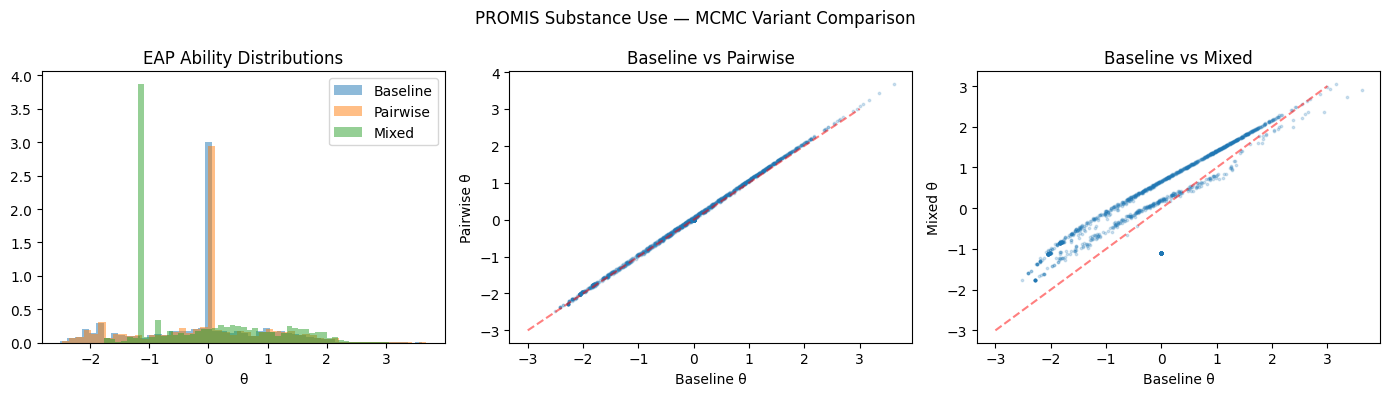

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# EAP distributions
for eap, label in [(eap_baseline, 'Baseline'), (eap_pairwise, 'Pairwise'), (eap_mixed, 'Mixed')]:
    if eap is not None:
        axes[0].hist(eap, bins=50, density=True, alpha=0.5, label=label)
axes[0].set_title('EAP Ability Distributions')
axes[0].set_xlabel('θ')
axes[0].legend()

# Baseline vs Pairwise scatter
if eap_pairwise is not None:
    axes[1].scatter(eap_baseline, eap_pairwise, alpha=0.2, s=3)
    axes[1].plot([-3, 3], [-3, 3], 'r--', alpha=0.5)
    axes[1].set_xlabel('Baseline θ')
    axes[1].set_ylabel('Pairwise θ')
    axes[1].set_title('Baseline vs Pairwise')

# Baseline vs Mixed scatter
if eap_mixed is not None:
    axes[2].scatter(eap_baseline, eap_mixed, alpha=0.2, s=3)
    axes[2].plot([-3, 3], [-3, 3], 'r--', alpha=0.5)
    axes[2].set_xlabel('Baseline θ')
    axes[2].set_ylabel('Mixed θ')
    axes[2].set_title('Baseline vs Mixed')

fig.suptitle('PROMIS Substance Use — MCMC Variant Comparison')
fig.tight_layout()
fig.savefig('mcmc_variant_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

## Summary

Ran marginal MCMC (NUTS with Rao-Blackwellized abilities) for three
model variants on PROMIS Substance Use:
- **Baseline**: ignorable missingness
- **Pairwise**: pairwise ordinal stacking imputation
- **Mixed**: pairwise + IRT blended imputation

4 chains × 500 samples each.